In [2]:
library(arrow)      # For reading parquet
library(dplyr)      # For data manipulation
library(tidyr)
library(ggplot2)    # For plotting
library(skimr)      # For quick summary
library(data.table) # For efficient large data handling
library(lubridate)


Attaching package: ‘arrow’




The following object is masked from ‘package:utils’:

    timestamp





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




...

The following objects are masked from ‘package:dplyr’:

    between, first, last





Attaching package: ‘lubridate’




The following objects are masked from ‘package:data.table’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following object is masked from ‘package:arrow’:

    duration




The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




# Detailed explanation of the fields in the dataset

## Core Trip Information
VendorID: Company providing the taxi service (1=Creative Mobile Technologies, 2=VeriFone)

tpep_pickup_datetime: Date/time when passenger was picked up (TPEP = Taxi & Limousine Commission's Trip Record System)

tpep_dropoff_datetime: Date/time when passenger was dropped off

passenger_count: Number of passengers in the vehicle (1-6, filtered in your cleaned data)

## Location Data
trip_distance: Distance traveled in miles (as reported by the taximeter)

RatecodeID: Fare type:

1 = Standard rate

2 = JFK airport

3 = Newark airport

4 = Nassau/Westchester

5 = Negotiated fare

6 = Group ride

99 = Other (appears in your data)

PULocationID: Taxi zone where passenger was picked up (mapping to actual locations available from NYC TLC)

DOLocationID: Taxi zone where passenger was dropped off

## Payment Details
payment_type:

1 = Credit card

2 = Cash

3 = No charge

4 = Dispute

5 = Unknown

6 = Voided trip

fare_amount: Base fare (time and distance)

extra: Additional charges:

$0.50 overnight (8pm-6am)

$1.00 peak hour (4pm-8pm weekdays)

$2.50 for JFK trips

mta_tax: $0.50 Metropolitan Transportation Authority tax

tip_amount: Driver tip (usually $0 for cash payments)

tolls_amount: Bridge/tunnel tolls

improvement_surcharge: $1.00 fee for system improvements

total_amount: Sum of all charges (fare + extras + taxes + tips + tolls)

congestion_surcharge: $2.50 fee for trips in Manhattan south of 96th St (since 2019)

airport_fee: $1.25 for trips to/from JFK or Newark airports

Additional Notes:
store_and_fwd_flag: "Y" if vehicle was offline and stored trip data locally before forwarding to system

In [2]:
# Read only 10,000 rows for now
full_data <- read_parquet("/kaggle/input/nyc-yellowtaxidata-january/yellow_tripdata_2023-01.parquet")
small_sample <- full_data %>% sample_n(10000)

In [3]:
# skim(small_sample)     # Summary of each column

In [5]:
summary(small_sample)  # Built-in summary

    VendorID     tpep_pickup_datetime            
 Min.   :1.000   Min.   :2023-01-01 00:10:51.00  
 1st Qu.:1.000   1st Qu.:2023-01-09 17:02:29.75  
 Median :2.000   Median :2023-01-17 10:34:18.50  
 Mean   :1.733   Mean   :2023-01-17 00:45:26.52  
 3rd Qu.:2.000   3rd Qu.:2023-01-24 14:11:53.75  
 Max.   :2.000   Max.   :2023-01-31 23:43:30.00  
                                                 
 tpep_dropoff_datetime            passenger_count trip_distance   
 Min.   :2023-01-01 00:22:48.00   Min.   :0.000   Min.   : 0.000  
 1st Qu.:2023-01-09 17:14:29.75   1st Qu.:1.000   1st Qu.: 1.060  
 Median :2023-01-17 10:56:13.00   Median :1.000   Median : 1.795  
 Mean   :2023-01-17 01:01:14.59   Mean   :1.352   Mean   : 3.351  
 3rd Qu.:2023-01-24 14:25:26.50   3rd Qu.:1.000   3rd Qu.: 3.320  
 Max.   :2023-02-01 00:06:08.00   Max.   :6.000   Max.   :40.250  
                                  NA's   :242                     
   RatecodeID     store_and_fwd_flag  PULocationID    DOLocation

In [6]:
head(small_sample)     # First few rows

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
<int>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2023-01-09 16:16:45,2023-01-09 16:30:14,1,2.06,1,N,230,107,1,14.2,2.5,0.5,3.00,0.00,1,23.70,2.5,0.00
2,2023-01-08 14:00:23,2023-01-08 14:12:47,1,1.67,1,N,249,148,1,12.8,0.0,0.5,2.00,0.00,1,18.80,2.5,0.00
2,2023-01-15 14:03:36,2023-01-15 14:20:10,1,2.69,1,N,48,263,1,17.7,0.0,0.5,3.00,0.00,1,24.70,2.5,0.00
2,2023-01-26 13:20:51,2023-01-26 13:27:44,1,1.31,1,N,162,141,2,9.3,0.0,0.5,0.00,0.00,1,13.30,2.5,0.00
2,2023-01-03 15:46:57,2023-01-03 15:59:12,1,1.56,1,N,164,163,1,12.8,0.0,0.5,3.36,0.00,1,20.16,2.5,0.00
2,2023-01-01 13:23:19,2023-01-01 14:06:02,1,17.94,2,N,132,48,1,70.0,0.0,0.5,16.11,6.55,1,97.91,2.5,1.25


In [6]:
#Cleaning and Mutating the data

cleaned_sample <- small_sample %>%
  filter(
    fare_amount > 0,
    total_amount > 0,
    trip_distance > 0 & trip_distance < 50,
    passenger_count >= 1 & passenger_count <= 6
  ) %>%
drop_na()  # removes rows with NA

In [8]:
# Done with basic cleaning of the data. Starting with Exploratory Data Analysis(EDA)
# After cleaning, I got the rows from 10000 to 9369

str(cleaned_sample)
dim(cleaned_sample)    # Rows and columns
head(cleaned_sample)   # First few rows

tibble [9,392 × 19] (S3: tbl_df/tbl/data.frame)
 $ VendorID             : int [1:9392] 2 2 2 2 2 2 2 2 2 2 ...
 $ tpep_pickup_datetime : POSIXct[1:9392], format: "2023-01-09 16:16:45" "2023-01-08 14:00:23" ...
 $ tpep_dropoff_datetime: POSIXct[1:9392], format: "2023-01-09 16:30:14" "2023-01-08 14:12:47" ...
 $ passenger_count      : num [1:9392] 1 1 1 1 1 1 1 1 1 1 ...
 $ trip_distance        : num [1:9392] 2.06 1.67 2.69 1.31 1.56 ...
 $ RatecodeID           : num [1:9392] 1 1 1 1 1 2 1 1 1 1 ...
 $ store_and_fwd_flag   : chr [1:9392] "N" "N" "N" "N" ...
 $ PULocationID         : int [1:9392] 230 249 48 162 164 132 107 231 170 141 ...
 $ DOLocationID         : int [1:9392] 107 148 263 141 163 48 234 158 90 236 ...
 $ payment_type         : int [1:9392] 1 1 1 2 1 1 2 1 2 2 ...
 $ fare_amount          : num [1:9392] 14.2 12.8 17.7 9.3 12.8 70 9.3 11.4 11.4 5.8 ...
 $ extra                : num [1:9392] 2.5 0 0 0 0 0 1 1 0 0 ...
 $ mta_tax              : num [1:9392] 0.5 0.5 0.5 0.5 0.5 

[1] 9392   19

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
<int>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2023-01-09 16:16:45,2023-01-09 16:30:14,1,2.06,1,N,230,107,1,14.2,2.5,0.5,3.00,0.00,1,23.70,2.5,0.00
2,2023-01-08 14:00:23,2023-01-08 14:12:47,1,1.67,1,N,249,148,1,12.8,0.0,0.5,2.00,0.00,1,18.80,2.5,0.00
2,2023-01-15 14:03:36,2023-01-15 14:20:10,1,2.69,1,N,48,263,1,17.7,0.0,0.5,3.00,0.00,1,24.70,2.5,0.00
2,2023-01-26 13:20:51,2023-01-26 13:27:44,1,1.31,1,N,162,141,2,9.3,0.0,0.5,0.00,0.00,1,13.30,2.5,0.00
2,2023-01-03 15:46:57,2023-01-03 15:59:12,1,1.56,1,N,164,163,1,12.8,0.0,0.5,3.36,0.00,1,20.16,2.5,0.00
2,2023-01-01 13:23:19,2023-01-01 14:06:02,1,17.94,2,N,132,48,1,70.0,0.0,0.5,16.11,6.55,1,97.91,2.5,1.25


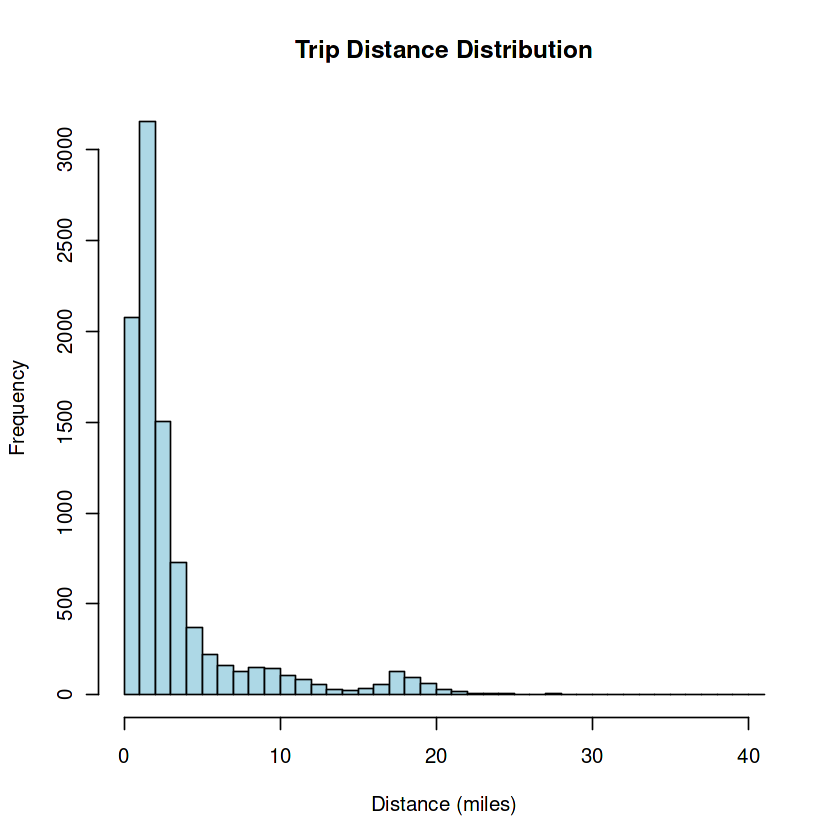

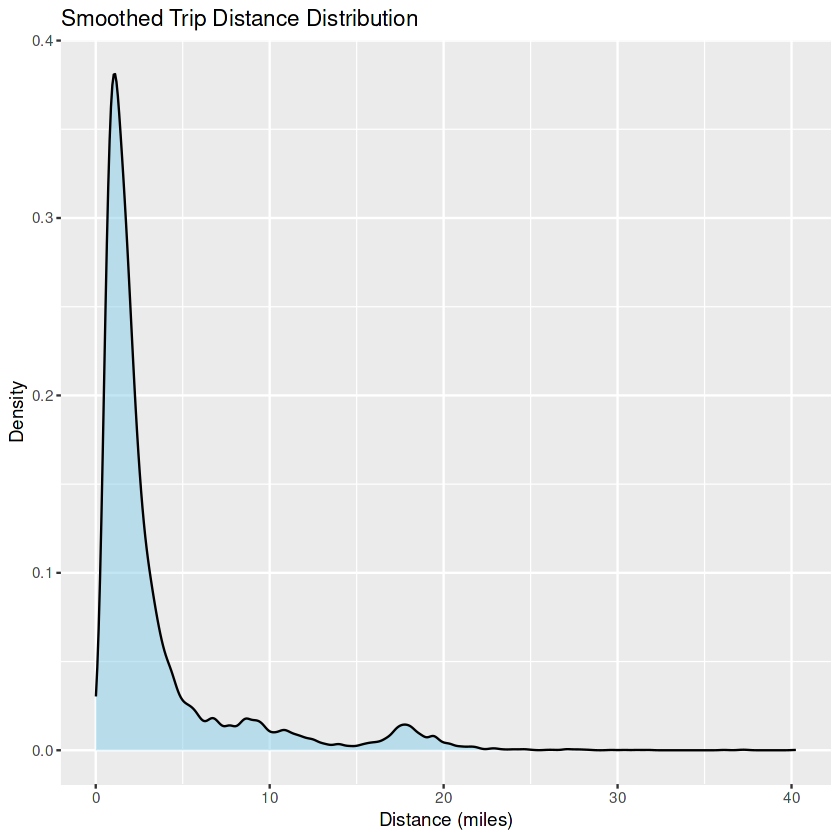

In [9]:
# Trip Distance distribution

hist(cleaned_sample$trip_distance,
     main = "Trip Distance Distribution",
     xlab = "Distance (miles)",
     col = "lightblue",
     breaks = 50)

# Smoothed version of the above graph

ggplot(cleaned_sample, aes(x = trip_distance)) +
  geom_density(fill = "skyblue", alpha = 0.5) +
  labs(title = "Smoothed Trip Distance Distribution", x = "Distance (miles)", y = "Density")

Inference:
The majority of trips are short – most are less than 5 miles.
This is a classic right-skewed distribution (a long tail of longer trips).
Outliers exist (trips > 20 miles), but they are rare.

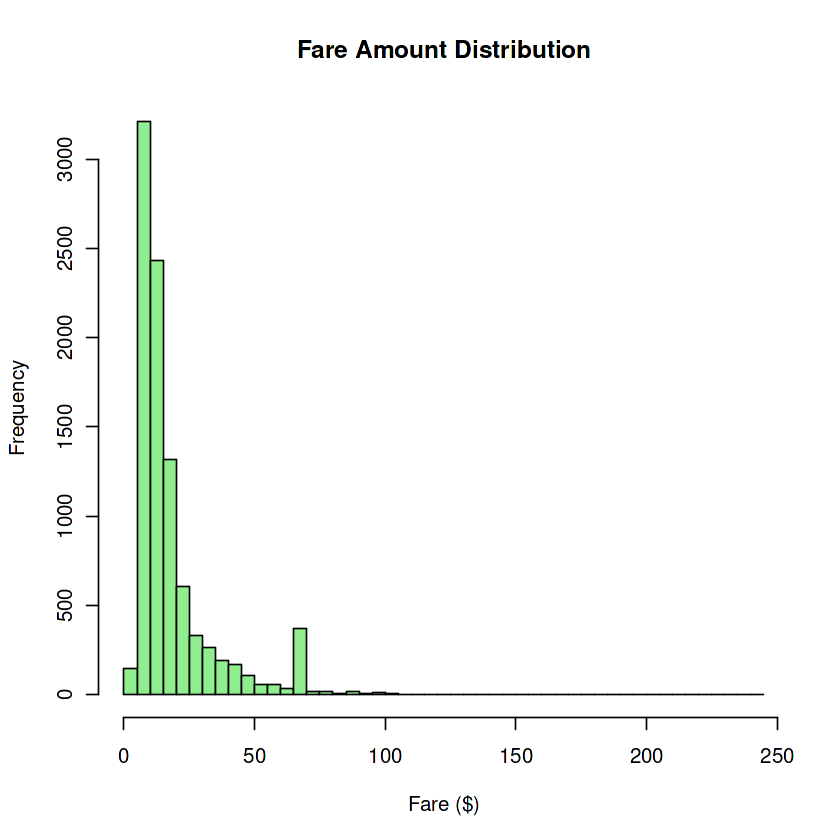

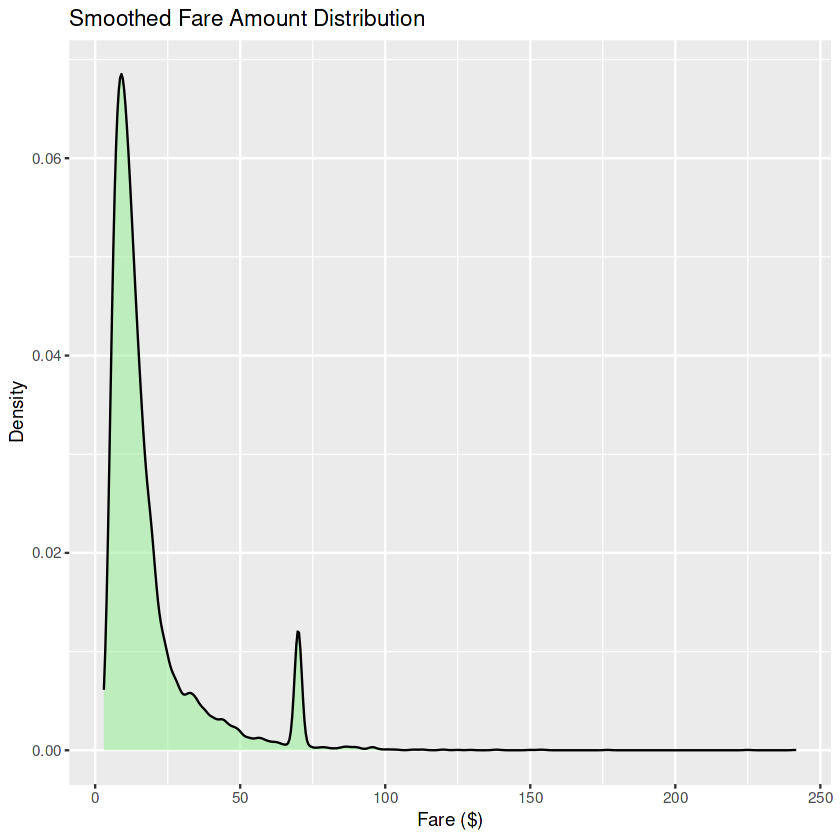

In [10]:
#Fare amount distribution

hist(cleaned_sample$fare_amount,
     main = "Fare Amount Distribution",
     xlab = "Fare ($)",
     col = "lightgreen",
     breaks = 50)

# Smoothed version of the above graph

ggplot(cleaned_sample, aes(x = fare_amount)) +
  geom_density(fill = "lightgreen", alpha = 0.5) +
  labs(title = "Smoothed Fare Amount Distribution", x = "Fare ($)", y = "Density")

Inference:
Most fares are under 30 dollars, 
and it also shows a right-skewed pattern.
There is an unusual spike around 60 - $70, which might indicate a fixed fare (e.g., airport rides) or rounding in billing.

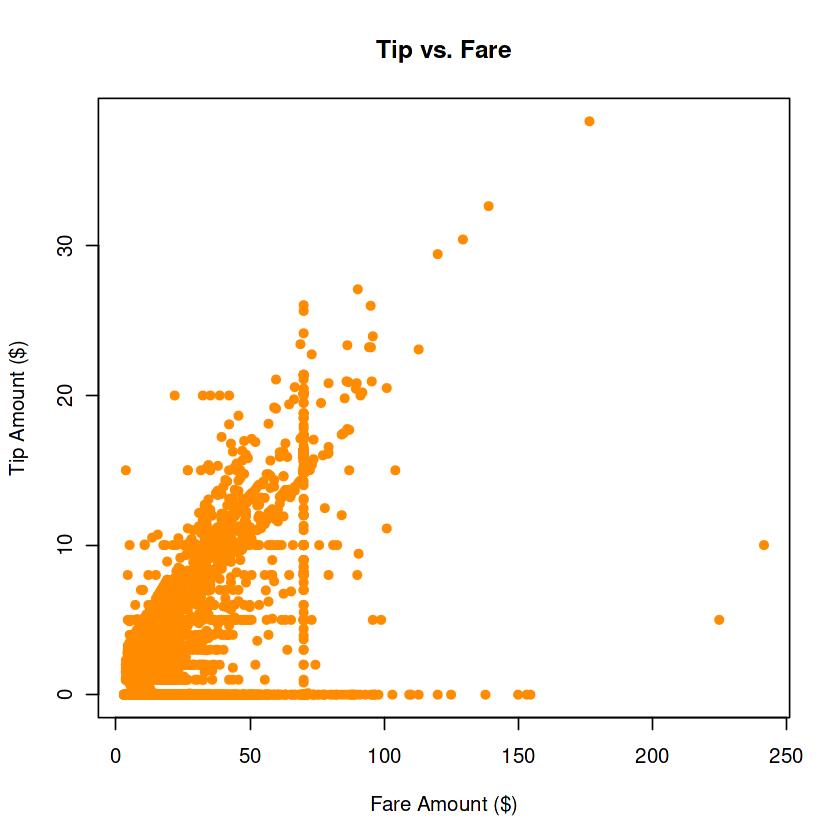

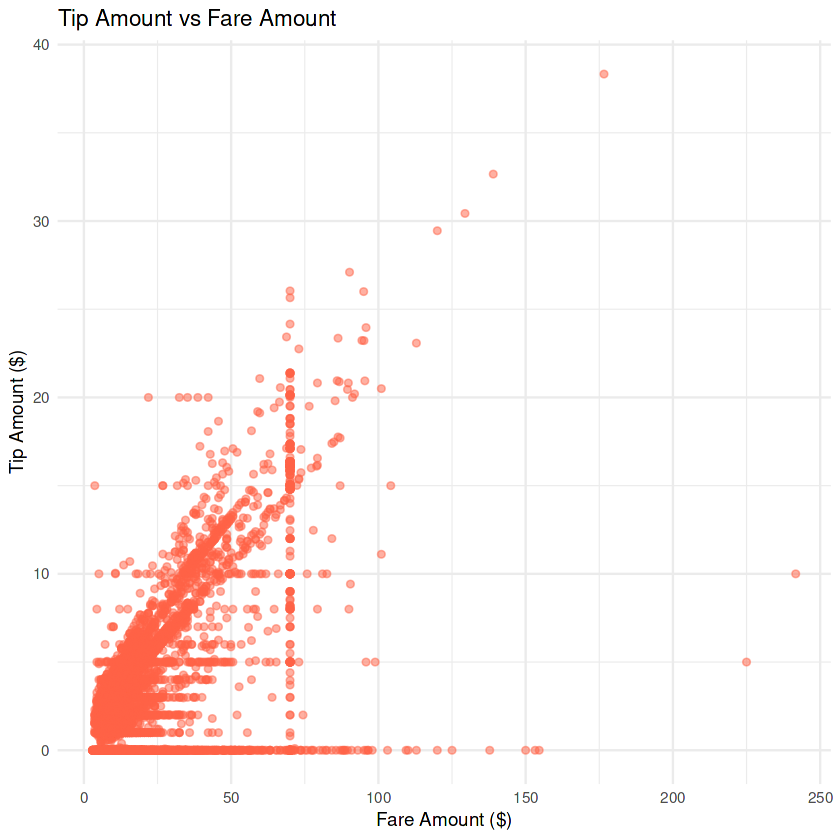

In [11]:
# Tip vs. Fare

plot(cleaned_sample$fare_amount, cleaned_sample$tip_amount,
     main = "Tip vs. Fare",
     xlab = "Fare Amount ($)",
     ylab = "Tip Amount ($)",
     col = "darkorange", pch = 16)

# This is the same graph as for Tip vs. Fare but the smoothed version for it

ggplot(cleaned_sample, aes(x = fare_amount, y = tip_amount)) +
  geom_point(alpha = 0.5, color = "tomato") +
  labs(title = "Tip Amount vs Fare Amount",
       x = "Fare Amount ($)",
       y = "Tip Amount ($)") +
  theme_minimal()

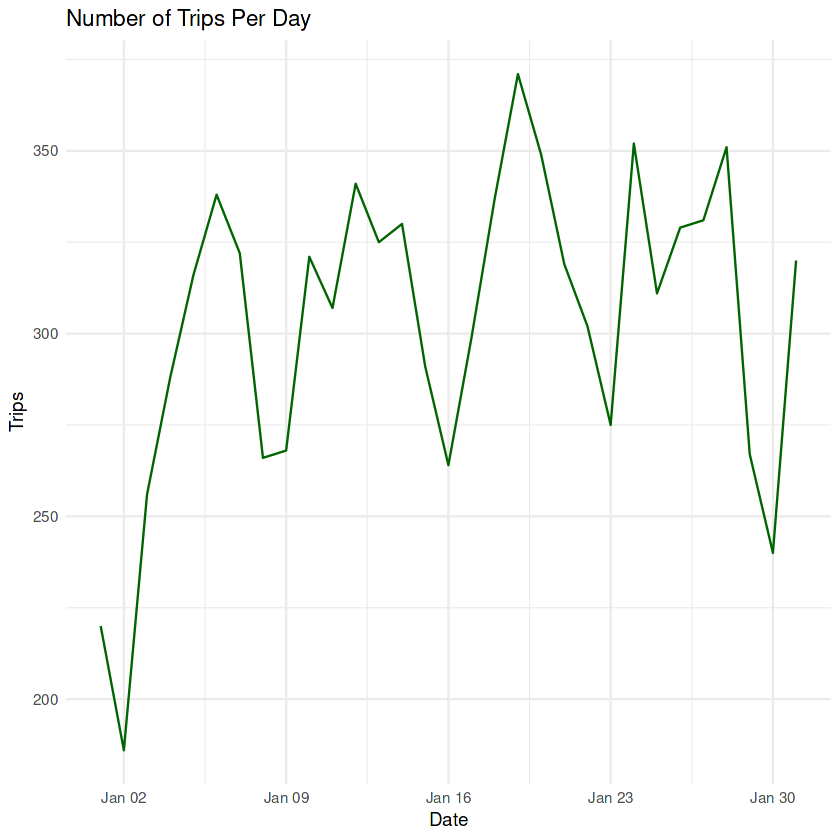

In [12]:
# Number of Trips over Time (Daily Trends)
# The code below is to understand the volume of trips per day which would be useful to detect peak days, seasonal dips, or it could even indicate outliers

cleaned_sample %>%
  mutate(date = as.Date(tpep_pickup_datetime)) %>%
  count(date) %>%
  ggplot(aes(x = date, y = n)) +
  geom_line(color = "darkgreen") +
  labs(title = "Number of Trips Per Day",
       x = "Date", y = "Trips") +
  theme_minimal()

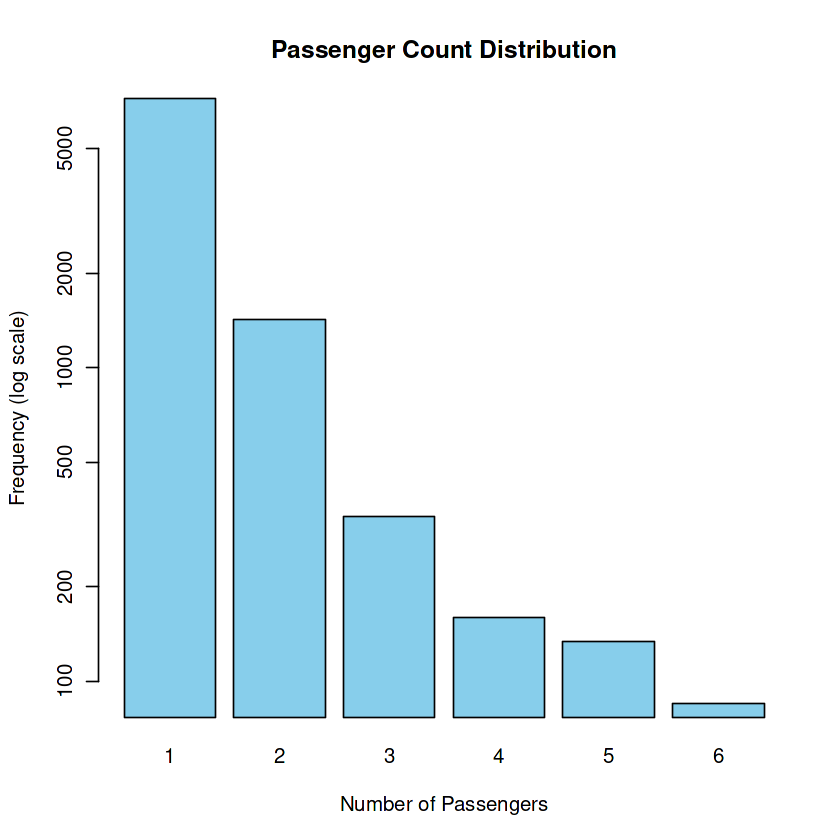

In [13]:
# Passenger Count Distribution
# This shows common trip group sizes which could be useful for policy decisions, fare structure, etc.

# I am using a log scale for Y axis so that I can understand the small values better that are close to the X-axis
barplot(table(cleaned_sample$passenger_count),
        main = "Passenger Count Distribution",
        xlab = "Number of Passengers",
        ylab = "Frequency (log scale)",
        col = "skyblue",
        log = "y")  # Apply logarithmic scale to Y-axis

In [ ]:
# Temporal patterns-- Exploring hourly and weekday trends in pickup times

# cleaned_sample %>%
#   mutate(hour = hour(tpep_pickup_datetime),
#          weekday = wday(tpep_pickup_datetime, label = TRUE)) %>%
#   count(hour, weekday) %>%
#   ggplot(aes(x = hour, y = n, fill = weekday)) +
#   geom_col(position = "dodge") +
#   labs(title = "Trips by Hour and Day of Week",
#        x = "Hour of Day", y = "Trip Count", fill = "Day") +
#   theme_minimal()

cleaned_sample %>%
  mutate(
    hour = hour(tpep_pickup_datetime),
    weekday_num = wday(tpep_pickup_datetime),
    weekday = factor(weekday_num, levels = 1:7, labels = c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"))
  ) %>%
  count(hour, weekday) %>%
  ggplot(aes(x = hour, y = n, fill = weekday)) +
  geom_col(position = "dodge") +
  labs(title = "Trips by Hour and Day of Week",
       x = "Hour of Day", y = "Trip Count", fill = "Day") +
  theme_minimal()

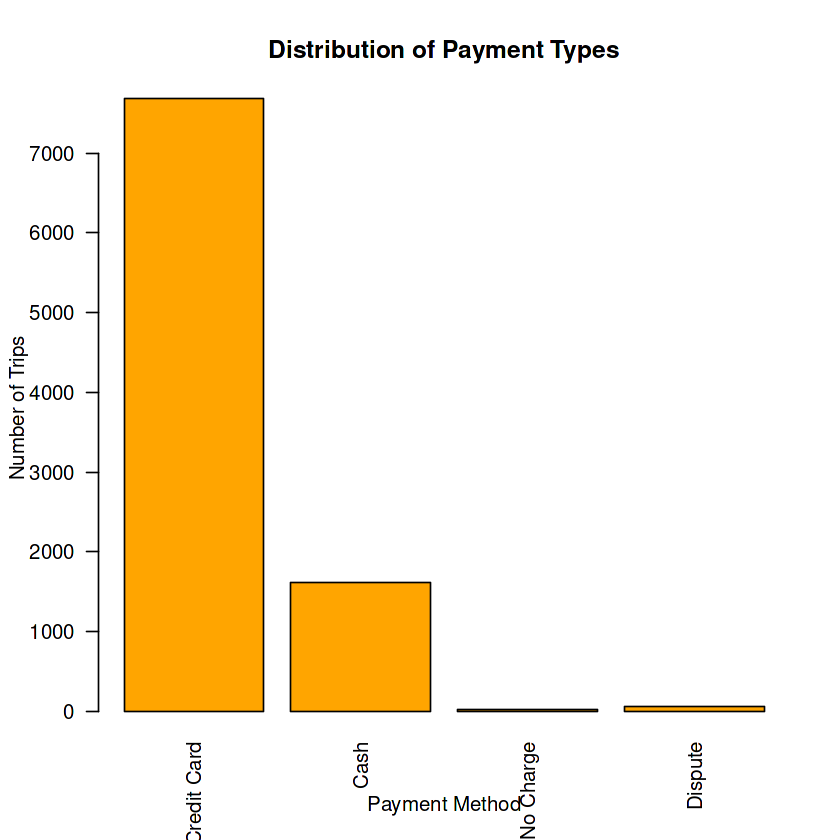

In [15]:
# Payment type distribution

# Define label names
payment_labels <- c("1" = "Credit Card",
                    "2" = "Cash",
                    "3" = "No Charge",
                    "4" = "Dispute",
                    "5" = "Unknown",
                    "6" = "Voided Trip")

# Create frequency table and label it
payment_counts <- table(cleaned_sample$payment_type)
names(payment_counts) <- payment_labels[names(payment_counts)]

# Plot
barplot(payment_counts,
        main = "Distribution of Payment Types",
        xlab = "Payment Method",
        ylab = "Number of Trips",
        col = "orange",
        las = 2)


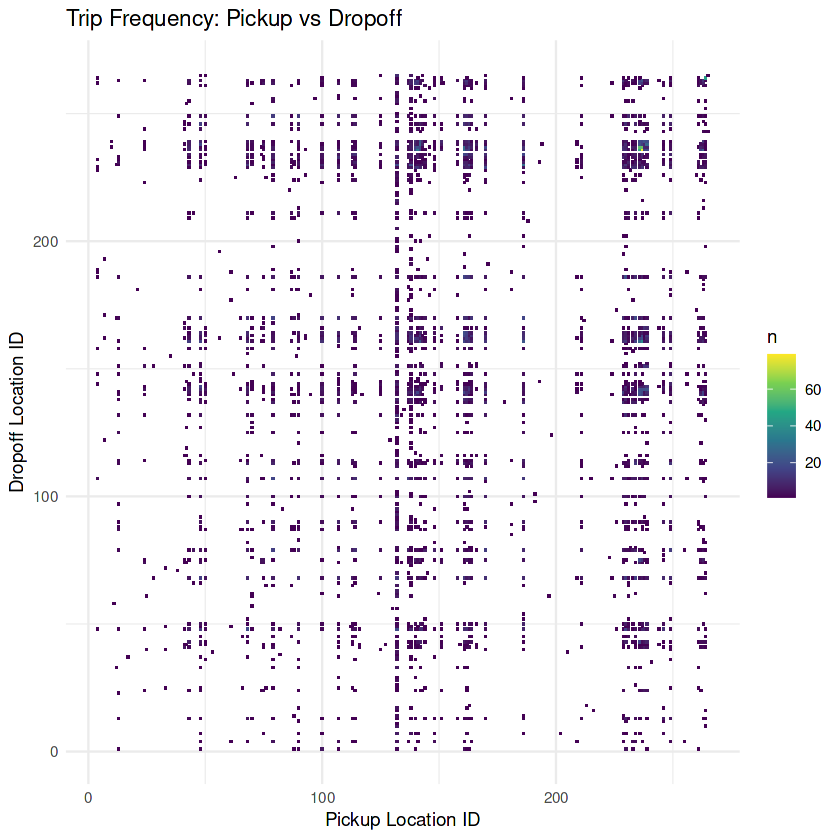

In [16]:
# Heatmap of Pickup vs DropOff location
# To explore spatial analysis

cleaned_sample %>%
  count(PULocationID, DOLocationID) %>%
  ggplot(aes(x = PULocationID, y = DOLocationID, fill = n)) +
  geom_tile() +
  scale_fill_viridis_c() +
  labs(title = "Trip Frequency: Pickup vs Dropoff",
       x = "Pickup Location ID", y = "Dropoff Location ID") +
  theme_minimal()

In [17]:
# Trip duration Analysis
# The duration of the trip is not directly available. Hence it is calculated and then visualised
cleaned_sample <- cleaned_sample %>%
  mutate(trip_duration = as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins")))

summary(cleaned_sample$trip_duration)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
   0.0333    7.1333   11.5000   15.9639   18.2042 1437.5167 

From the above summary, I understood that the avg. duration is 15 minutes
Statistic	Value (mins)	Interpretation
Minimum	0.000	Likely an error or extremely short trip (needs checking).
1st Quartile (Q1)	7.233	25% of trips are shorter than ~7.2 minutes.
Median (Q2)	11.683	Half of all trips are under ~11.7 minutes.
Mean	15.218	Average trip duration is ~15.2 minutes. Higher than median due to some long trips.
3rd Quartile (Q3)	18.321	75% of trips are shorter than ~18.3 minutes.
Maximum	1434.400	Nearly 24 hours — likely an outlier or data entry issue.

Warning message:
“Removed 13 rows containing non-finite outside the scale range (`stat_bin()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


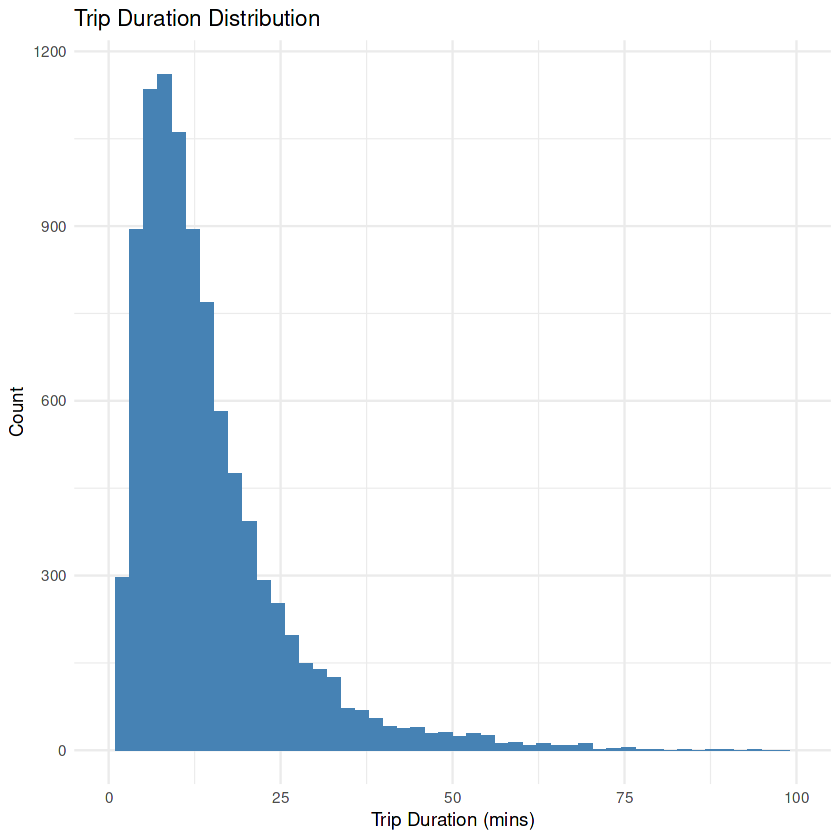

In [18]:
# Plot distribution
ggplot(cleaned_sample, aes(x = trip_duration)) +
  geom_histogram(bins = 50, fill = "steelblue") +
  xlim(0, 100) +  # Optional to avoid extreme values
  labs(title = "Trip Duration Distribution", x = "Trip Duration (mins)", y = "Count") +
  theme_minimal()
# The graph just goes on to solidify the above inferences
# This plot also takes care of the outliers - Primarily trips that are near 24 hours

`geom_smooth()` using formula = 'y ~ x'


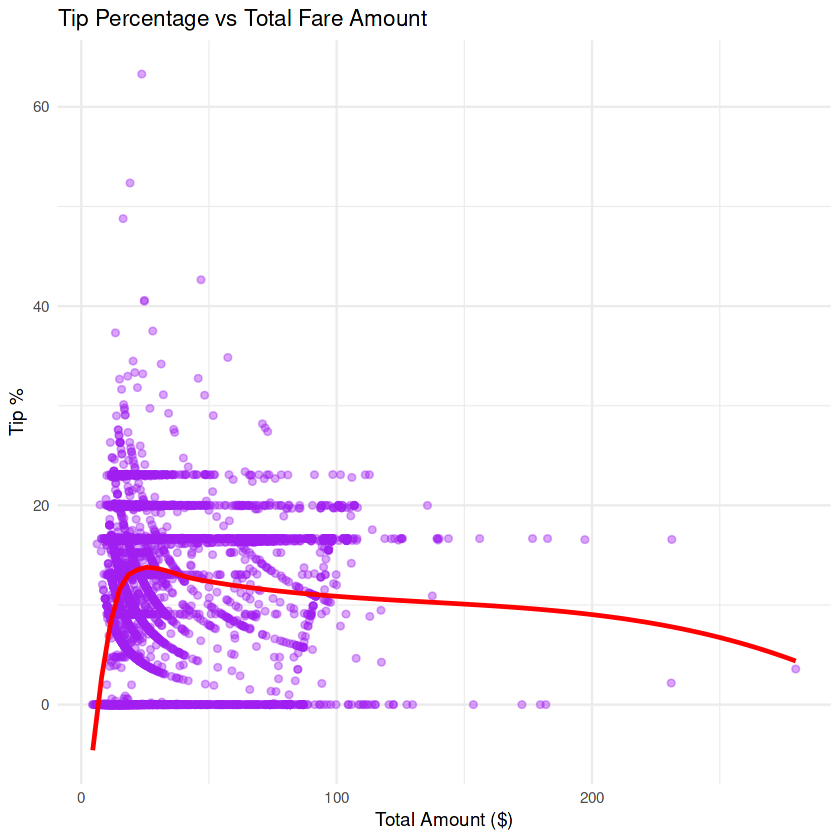

In [19]:
# Tip Percentage vs. Total amount

cleaned_sample <- cleaned_sample %>%
  mutate(tip_pct = (tip_amount / total_amount) * 100)

ggplot(cleaned_sample, aes(x = total_amount, y = tip_pct)) +
  geom_point(alpha = 0.4, color = "purple") +
  geom_smooth(se = FALSE, method = "loess", color = "red") +
  labs(title = "Tip Percentage vs Total Fare Amount", x = "Total Amount ($)", y = "Tip %") +
  theme_minimal()


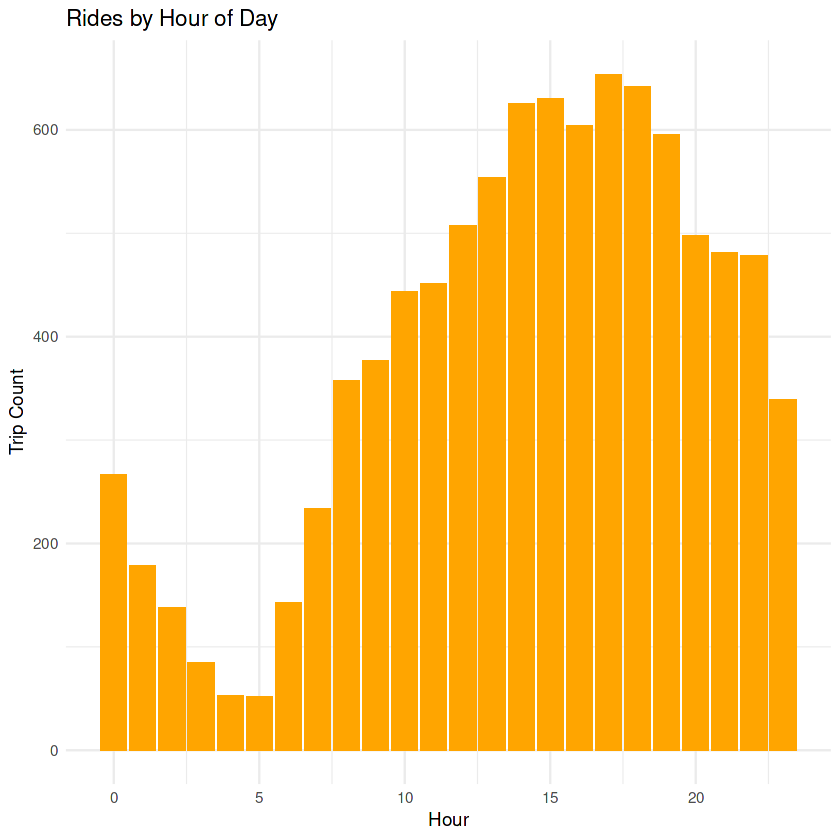

In [20]:
# Time of Day analysis
# Group rides by hour of day to analyze peak times.

cleaned_sample %>%
  mutate(hour = hour(tpep_pickup_datetime)) %>%
  count(hour) %>%
  ggplot(aes(x = hour, y = n)) +
  geom_col(fill = "orange") +
  labs(title = "Rides by Hour of Day", x = "Hour", y = "Trip Count") +
  theme_minimal()


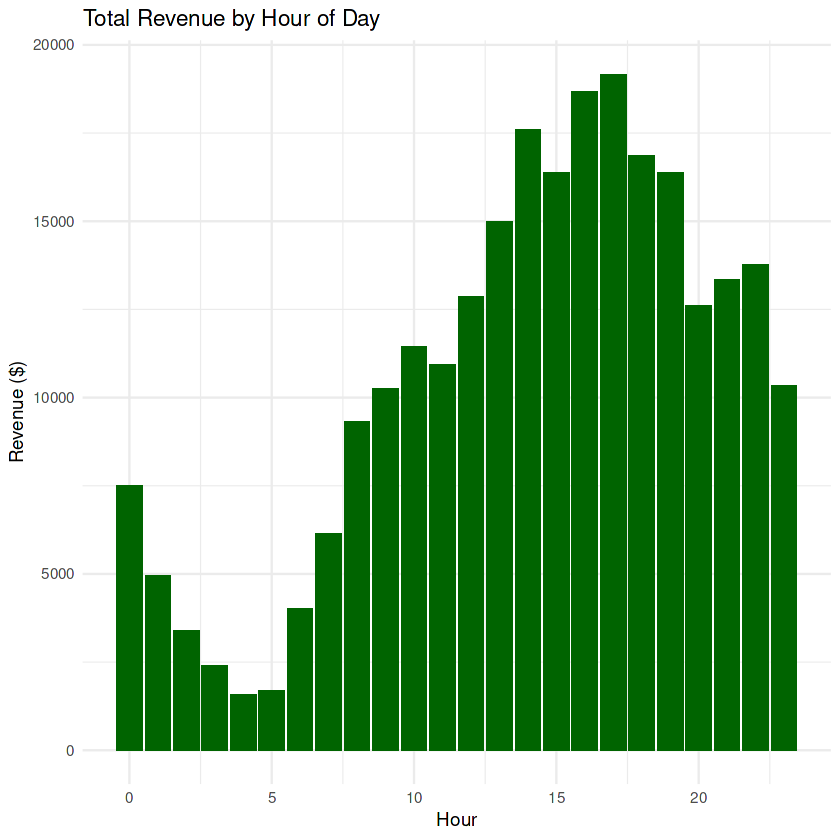

In [21]:
## Revenue analysis by hour/day
# Revenue analysis by Hour of Day

library(lubridate)

cleaned_sample %>%
  mutate(hour = hour(tpep_pickup_datetime)) %>%
  group_by(hour) %>%
  summarise(revenue = sum(total_amount, na.rm = TRUE)) %>%
  ggplot(aes(x = hour, y = revenue)) +
  geom_col(fill = "darkgreen") +
  labs(title = "Total Revenue by Hour of Day", x = "Hour", y = "Revenue ($)") +
  theme_minimal()


In [ ]:
# Revenue by day of Week

# cleaned_sample %>%
#   mutate(weekday = wday(tpep_pickup_datetime, label = TRUE)) %>%
#   group_by(weekday) %>%
#   summarise(revenue = sum(total_amount, na.rm = TRUE)) %>%
#   ggplot(aes(x = weekday, y = revenue)) +
#   geom_col(fill = "steelblue") +
#   labs(title = "Total Revenue by Day of Week", x = "Day", y = "Revenue ($)") +
#   theme_minimal()

cleaned_sample %>%
  mutate(
    weekday_num = wday(tpep_pickup_datetime),  # returns 1 (Sun) to 7 (Sat)
    weekday = factor(weekday_num, levels = 1:7, 
                     labels = c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"))
  ) %>%
  group_by(weekday) %>%
  summarise(revenue = sum(total_amount, na.rm = TRUE)) %>%
  ggplot(aes(x = weekday, y = revenue)) +
  geom_col(fill = "steelblue") +
  labs(title = "Total Revenue by Day of Week", x = "Day", y = "Revenue ($)") +
  theme_minimal()


Selecting by n


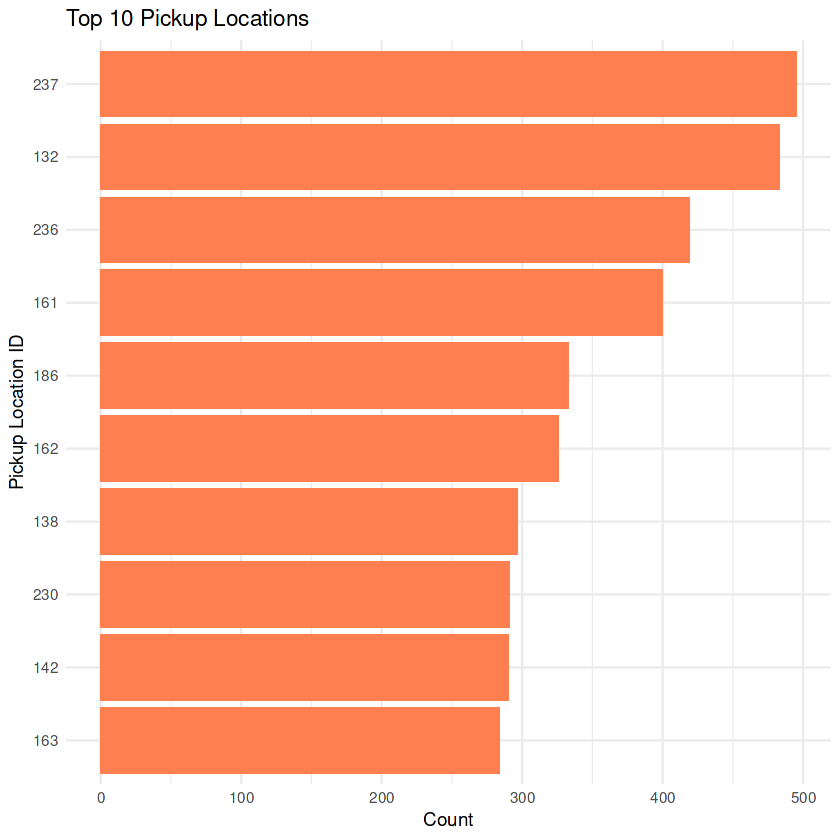

In [23]:
# Trying to generate Geospatial insights

cleaned_sample %>%
  count(PULocationID, sort = TRUE) %>%
  top_n(10) %>%
  ggplot(aes(x = reorder(as.factor(PULocationID), n), y = n)) +
  geom_col(fill = "coral") +
  labs(title = "Top 10 Pickup Locations", x = "Pickup Location ID", y = "Count") +
  coord_flip() +
  theme_minimal()


In [24]:
# Simple linear model for identifying variables that are good predictors of the tip amount

model_data <- cleaned_sample %>%
  select(tip_amount, fare_amount, trip_distance, passenger_count, total_amount)

model <- lm(tip_amount ~ ., data = model_data)
summary(model)



Call:
lm(formula = tip_amount ~ ., data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.3496  -0.6601   0.1243   0.7389  10.0941 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -1.718768   0.045140 -38.076   <2e-16 ***
fare_amount     -0.546893   0.005698 -95.977   <2e-16 ***
trip_distance   -0.114198   0.013192  -8.657   <2e-16 ***
passenger_count -0.020861   0.019578  -1.066    0.287    
total_amount     0.571980   0.004180 136.821   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.654 on 9387 degrees of freedom
Multiple R-squared:  0.7901,	Adjusted R-squared:   0.79 
F-statistic:  8833 on 4 and 9387 DF,  p-value: < 2.2e-16


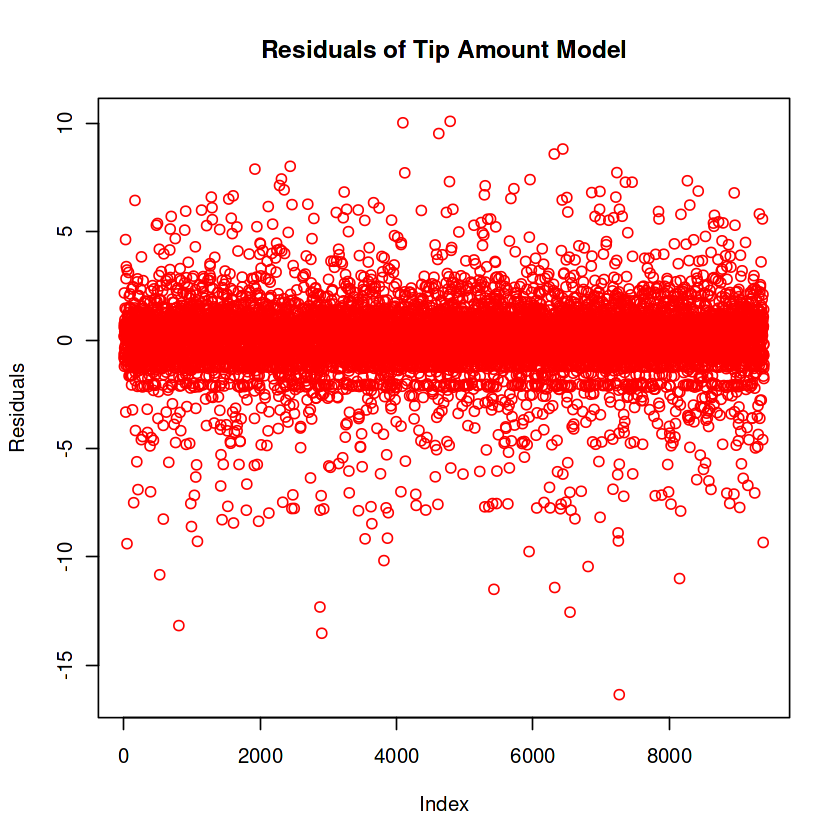

In [25]:
# Additional Residual Visualization

plot(model$residuals, main = "Residuals of Tip Amount Model", ylab = "Residuals", col = "red")


In [ ]:
lookup <- read.csv("/kaggle/input/taxi-zone-lookup-csv/taxi_zone_lookup.csv") 

In [ ]:
top_pu <- cleaned_sample %>%
  count(PULocationID, sort = TRUE) %>%
  top_n(10) %>%
  left_join(lookup, by = c("PULocationID" = "LocationID"))

ggplot(top_pu, aes(x = reorder(Zone, n), y = n)) +
  geom_col(fill = "coral") +
  coord_flip() +
  labs(title = "Top 10 Pickup Zones",
       x = "Pickup Zone",
       y = "Number of Trips") +
  theme_minimal()

In [ ]:
top_do <- cleaned_sample %>%
  count(DOLocationID, sort = TRUE) %>%
  top_n(10) %>%
  left_join(lookup, by = c("DOLocationID" = "LocationID"))

ggplot(top_do, aes(x = reorder(Zone, n), y = n)) +
  geom_col(fill = "dodgerblue") +
  coord_flip() +
  labs(title = "Top 10 Dropoff Zones",
       x = "Dropoff Zone",
       y = "Number of Trips") +
  theme_minimal()


### Beginning task of Comparing various regression models along with RNN

I'm using the tip_amount field to analyse different regression models

In [2]:
# Loading libraries

library(tidyverse)
library(arrow)         # For reading parquet files
library(caret)         # For data splitting
library(glmnet)        # For Ridge, Lasso, Elastic Net
library(polyreg)       # For Polynomial Regression
library(keras)         # For LSTM
library(recipes)       # For preprocessing pipeline
library(Metrics)       # For MAE, RMSE

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ purrr   1.0.2     ✔ tibble  3.2.1
✔ readr   2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between() masks dplyr::between()
✖ lubridate::duration() masks arrow::duration()
✖ dplyr::filter()       masks stats::filter()
✖ data.table::first()   masks dplyr::first()
✖ lubridate::hour()     masks data.table::hour()
✖ lubridate::isoweek()  masks data.table::isoweek()
✖ dplyr::lag()          masks stats::lag()
✖ data.table::last()    masks dplyr::last()
✖ lubridate::mday()     masks data.table::mday()
✖ lubridate::minute()   masks data.table::minute()
✖ lubridate::month()    masks data.table::month()
✖ lubridate::quarter()  masks data.table::quarter()
✖ lubridate::second()   masks data.table::second()
✖ purrr::transpose()    masks data.table::transpose()
✖ lubridate::wday()     masks data.table::wday()
✖ lubridate::we

In [3]:
# Load data

df <- read_parquet("/kaggle/input/nyc-yellowtaxidata-january/yellow_tripdata_2023-01.parquet")

In [4]:
# Basic preprocessing

df <- df %>%
  filter(tip_amount >= 0, fare_amount > 0, trip_distance > 0) %>%
  mutate(
    pickup_hour = hour(tpep_pickup_datetime),
    pickup_day_num = wday(tpep_pickup_datetime), 
    pickup_day = factor(pickup_day_num, levels = 1:7,
                        labels = c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat")),
    payment_type = as.factor(payment_type)
  ) %>%
  select(tip_amount, fare_amount, trip_distance, passenger_count,
         payment_type, pickup_hour, pickup_day) %>%
  drop_na()

# # Slice 8000 rows
# df <- df[1:8000, ]


In [5]:
# Train/Test Split

set.seed(123)
trainIndex <- createDataPartition(df$tip_amount, p = .7, list = FALSE)
train_data <- df[trainIndex, ]
test_data <- df[-trainIndex, ]

In [6]:
# Preprocessing recipe

rec <- recipe(tip_amount ~ ., data = train_data) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_center(all_numeric_predictors()) %>%
  step_scale(all_numeric_predictors()) %>%
  prep()

train_proc <- bake(rec, train_data)
test_proc <- bake(rec, test_data)

In [7]:
# Extracting x and y

x_train <- model.matrix(tip_amount ~ ., train_proc)[,-1]
y_train <- train_proc$tip_amount
x_test <- model.matrix(tip_amount ~ ., test_proc)[,-1]
y_test <- test_proc$tip_amount

In [8]:
# Linear Regression

lm_model <- lm(tip_amount ~ ., data = train_proc)
pred_lm <- predict(lm_model, newdata = test_proc)

In [9]:
# # Polynomial Regression (Degree 2)
# Dynamically create formula for Polynomial Regression

# Get all feature names (excluding the target)
feature_names <- colnames(train_proc)
feature_names <- feature_names[feature_names != "tip_amount"]

# For selected numeric features, apply poly()
poly_features <- c("fare_amount", "trip_distance")
other_features <- setdiff(feature_names, poly_features)

# Construct the formula parts
poly_terms <- paste0("poly(", poly_features, ", 2)")
all_terms <- c(poly_terms, other_features)

# Build the formula
poly_formula <- as.formula(paste("tip_amount ~", paste(all_terms, collapse = " + ")))

# Fit polynomial regression
poly_model <- lm(poly_formula, data = train_proc)

# Predict
pred_poly <- predict(poly_model, newdata = test_proc)


In [10]:
# Ridge regression

ridge_model <- cv.glmnet(x_train, y_train, alpha = 0)
pred_ridge <- predict(ridge_model, s = "lambda.min", newx = x_test)

In [12]:
# Lasso regression

lasso_model <- cv.glmnet(x_train, y_train, alpha = 1)
pred_lasso <- predict(lasso_model, s = "lambda.min", newx = x_test)

In [14]:
# Elastic Net

elastic_model <- cv.glmnet(x_train, y_train, alpha = 0.5)
pred_elastic <- predict(elastic_model, s = "lambda.min", newx = x_test)

In [ ]:
# LSTM (Keras)

x_train_lstm <- array(as.matrix(x_train), dim = c(nrow(x_train), ncol(x_train), 1))
x_test_lstm <- array(as.matrix(x_test), dim = c(nrow(x_test), ncol(x_test), 1))

model_lstm <- keras_model_sequential() %>%
  layer_lstm(units = 64, input_shape = c(ncol(x_train), 1), return_sequences = FALSE) %>%
  layer_dropout(rate = 0.2) %>%
  layer_dense(units = 32, activation = "relu") %>%
  layer_dense(units = 1)

model_lstm %>% compile(
  loss = 'mean_squared_error',
  optimizer = optimizer_adam()
)

early_stop <- callback_early_stopping(monitor = "val_loss", patience = 3, restore_best_weights = TRUE)

model_lstm %>% fit(
  x_train_lstm, y_train,
  epochs = 30,
  batch_size = 64,
  validation_split = 0.2,
  callbacks = list(early_stop),
  verbose = 1
)

pred_lstm <- model_lstm %>% predict(x_test_lstm)

In [ ]:
# Evaluation
# Mean Absolute Error (MAE)
# Root Mean Squared Error (RMSE)
# R^2 (Coefficient of Determination)

results <- tibble(
  Model = c("Linear", "Polynomial", "Ridge", "Lasso", "Elastic Net", "LSTM"),
  MAE = c(
    mae(y_test, pred_lm),
    mae(y_test, pred_poly),
    mae(y_test, pred_ridge),
    mae(y_test, pred_lasso),
    mae(y_test, pred_elastic),
    mae(y_test, pred_lstm)
  ),
  RMSE = c(
    rmse(y_test, pred_lm),
    rmse(y_test, pred_poly),
    rmse(y_test, pred_ridge),
    rmse(y_test, pred_lasso),
    rmse(y_test, pred_elastic),
    rmse(y_test, pred_lstm)
  ),
  R2 = c(
    R2(pred_lm, y_test),
    R2(pred_poly, y_test),
    R2(pred_ridge, y_test),
    R2(pred_lasso, y_test),
    R2(pred_elastic, y_test),
    R2(pred_lstm, y_test)
  )
)

print(results)